# Cryptocurrency Liquidity Prediction - EDA
## Exploratory Data Analysis

### Problem Statement
Cryptocurrency markets are highly volatile, and liquidity plays a crucial role in maintaining market stability. The objective is to predict cryptocurrency liquidity levels using historical market data.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
%matplotlib inline
print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Data Loading

In [2]:
# Load datasets
df1 = pd.read_csv('../data/raw/coin_gecko_2022-03-16.csv')
df2 = pd.read_csv('../data/raw/coin_gecko_2022-03-17.csv')

print(f'Dataset 1: {df1.shape}')
print(f'Dataset 2: {df2.shape}')

# Merge datasets
df = pd.concat([df1, df2], ignore_index=True)
print(f'\nCombined: {df.shape}')

Dataset 1: (500, 9)
Dataset 2: (500, 9)

Combined: (1000, 9)


In [3]:
# Preview data
df.head()

,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16


In [4]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   coin        1000 non-null   object 
 1   symbol      1000 non-null   object 
 2   price       1000 non-null   float64
 3   1h          993 non-null    float64
 4   24h         993 non-null    float64
 5   7d          992 non-null    float64
 6   24h_volume  993 non-null    float64
 7   mkt_cap     1000 non-null   float64
 8   date        1000 non-null   object 
dtypes: float64(6), object(3)
memory usage: 70.4+ KB


## 2. Data Cleaning

In [5]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal: {df.isnull().sum().sum()}')

Missing Values:
coin          0
symbol        0
price         0
1h            7
24h           7
7d            8
24h_volume    7
mkt_cap       0
date          0
dtype: int64

Total: 29


In [6]:
# Rename columns
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')

column_mapping = {
    'mkt_cap': 'market_cap',
    '24h_volume': 'volume_24h',
    '1h': 'change_1h',
    '24h': 'change_24h',
    '7d': 'change_7d'
}
df_clean = df_clean.rename(columns=column_mapping)
print('Columns:', df_clean.columns.tolist())

Columns: ['coin', 'symbol', 'price', 'change_1h', 'change_24h', 'change_7d', 'volume_24h', 'market_cap', 'date']


In [7]:
# Handle missing values
for col in ['change_1h', 'change_24h', 'change_7d']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

df_clean = df_clean.dropna(subset=['price', 'volume_24h', 'market_cap'])
print(f'Shape after cleaning: {df_clean.shape}')

Shape after cleaning: (993, 9)


## 3. Summary Statistics

In [8]:
df_clean.describe()

,price,change_1h,change_24h,change_7d,volume_24h,market_cap
count,9.930000e+02,993.000000,993.000000,993.000000,9.930000e+02,9.930000e+02
mean,6.194355e+02,0.009723,0.023737,0.023535,2.893109e+08,3.780941e+09
std,4.419811e+03,0.026934,0.059303,0.229667,2.769908e+09,3.817057e+10
min,1.484000e-09,-0.704000,-0.646000,-0.558000,0.000000e+00,6.577043e+07
25%,1.944270e-01,0.001000,0.001000,-0.041000,1.766976e+06,1.158653e+08
50%,1.100000e+00,0.006000,0.016000,0.000000,8.343005e+06,2.135646e+08
75%,7.150000e+00,0.019000,0.035000,0.037000,4.003652e+07,6.025829e+08
max,4.121727e+04,0.095000,0.577000,4.608000,5.793497e+10,7.760774e+11


In [9]:
print('=== KEY STATISTICS ===')
print(f"Cryptocurrencies: {df_clean['coin'].nunique()}")
print(f"Records: {len(df_clean)}")
print(f"Price Range: ${df_clean['price'].min():.6f} - ${df_clean['price'].max():,.2f}")
print(f"Total Market Cap: ${df_clean['market_cap'].sum()/1e12:.2f} Trillion")

=== KEY STATISTICS ===
Cryptocurrencies: 503
Records: 993
Price Range: $0.000000 - $41,217.27
Total Market Cap: $3.75 Trillion


## 4. Top Cryptocurrencies

In [11]:
# Top 10 by Market Cap
top_10 = df_clean.nlargest(10, 'market_cap')[['coin', 'symbol', 'price', 'volume_24h', 'market_cap']]
top_10

,coin,symbol,price,volume_24h,market_cap
500,Bitcoin,BTC,40851.380000,2.047612e+10,7.760774e+11
0,Bitcoin,BTC,40859.460000,3.539076e+10,7.709915e+11
501,Ethereum,ETH,2824.420000,1.364041e+10,3.390772e+11
1,Ethereum,ETH,2744.410000,1.974870e+10,3.271044e+11
502,Tether,USDT,1.000000,4.413140e+10,8.020588e+10
2,Tether,USDT,1.000000,5.793497e+10,7.996516e+10
503,BNB,BNB,389.610000,1.425354e+09,6.556116e+10
3,BNB,BNB,383.430000,1.395854e+09,6.404382e+10
504,USD Coin,USDC,0.999739,3.569816e+09,5.259607e+10
4,USD Coin,USDC,0.999874,3.872274e+09,5.222214e+10


In [26]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"   # Browser me khulega
fig = px.bar(top_10, x='coin', y='market_cap', color='market_cap',
             title='Top 10 Cryptocurrencies by Market Cap')
fig.show()

## 5. Price Distribution

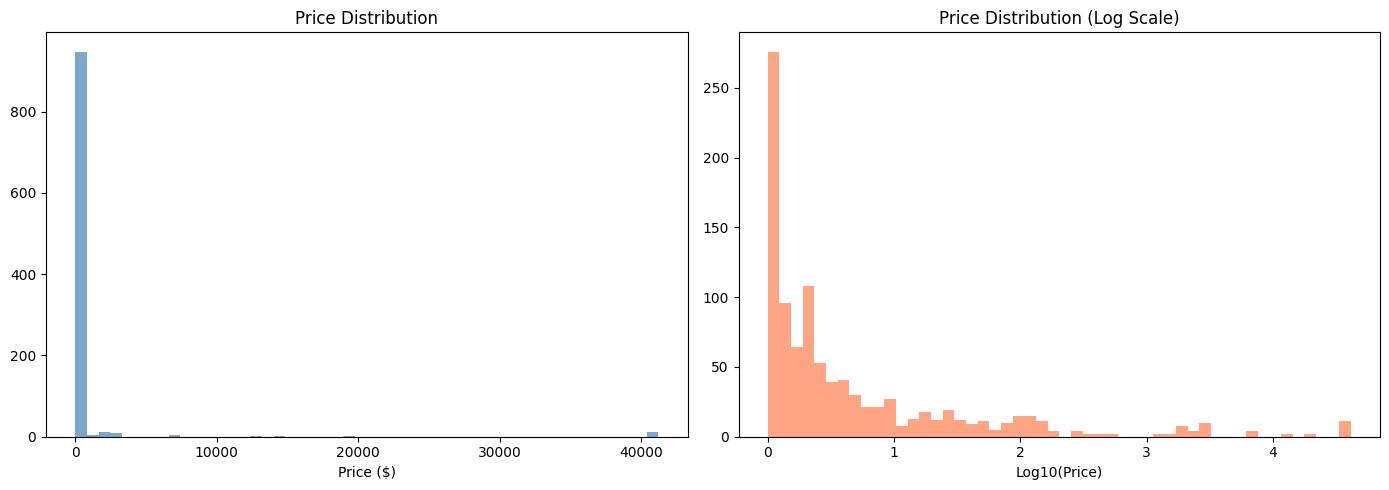

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['price'], bins=50, alpha=0.7, color='steelblue')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log10(df_clean['price'] + 1), bins=50, alpha=0.7, color='coral')
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('Log10(Price)')

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

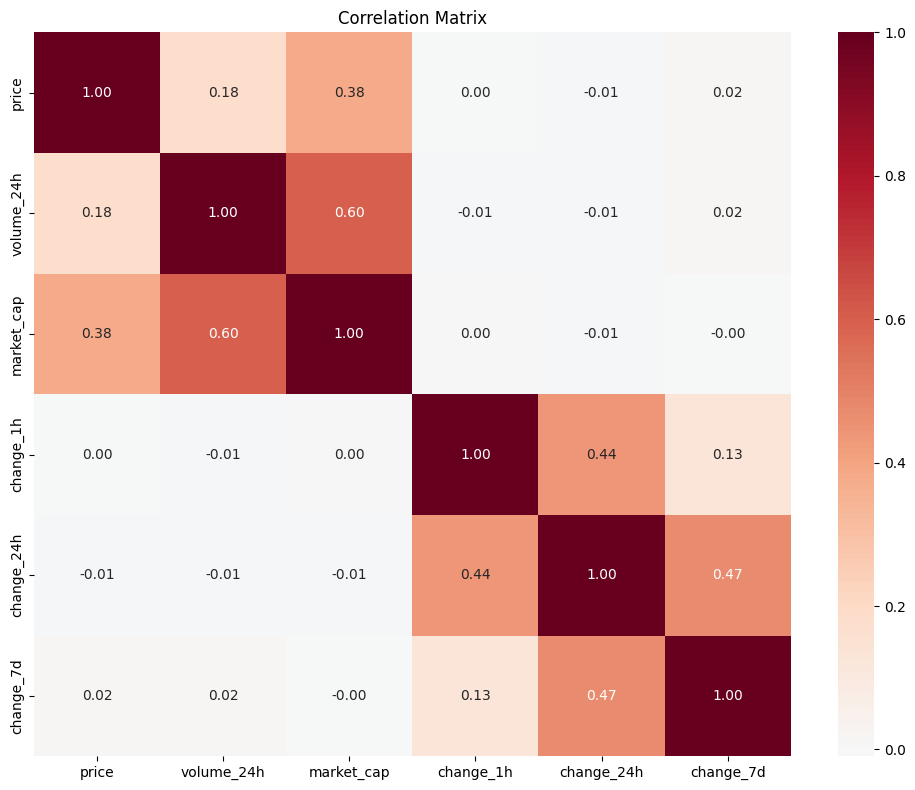

In [28]:
numeric_cols = ['price', 'volume_24h', 'market_cap', 'change_1h', 'change_24h', 'change_7d']
available = [c for c in numeric_cols if c in df_clean.columns]

corr = df_clean[available].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Liquidity Analysis

In [29]:
# Calculate liquidity ratio
df_clean['liquidity_ratio'] = df_clean['volume_24h'] / df_clean['market_cap']

print('Liquidity Ratio Stats:')
print(f"Mean: {df_clean['liquidity_ratio'].mean():.4f}")
print(f"Median: {df_clean['liquidity_ratio'].median():.4f}")

Liquidity Ratio Stats:
Mean: 0.1037
Median: 0.0338


In [30]:
# Top 10 most liquid
top_liquid = df_clean.nlargest(10, 'liquidity_ratio')[['coin', 'volume_24h', 'market_cap', 'liquidity_ratio']]
top_liquid

,coin,volume_24h,market_cap,liquidity_ratio
890,JasmyCoin,6.576315e+08,110553343.0,5.948545
409,JasmyCoin,4.802617e+08,99367227.0,4.833200
186,FLEX Coin,1.326196e+09,311600507.0,4.256079
692,FLEX Coin,1.321112e+09,311501806.0,4.241107
182,STEPN,1.013705e+09,318571623.0,3.182031
655,STEPN,1.358531e+09,456251258.0,2.977594
882,Alpine F1 Team Fan Token,2.266640e+08,114038968.0,1.987601
407,Alpine F1 Team Fan Token,1.535219e+08,99922202.0,1.536414
335,Polkastarter,2.001325e+08,135061007.0,1.481793
603,ApeCoin,1.129583e+09,794922002.0,1.420999


In [31]:
# Liquidity classification
q25 = df_clean['liquidity_ratio'].quantile(0.25)
q75 = df_clean['liquidity_ratio'].quantile(0.75)

df_clean['liquidity_class'] = df_clean['liquidity_ratio'].apply(
    lambda x: 'High' if x >= q75 else ('Medium' if x >= q25 else 'Low')
)

print('\nLiquidity Classification:')
print(df_clean['liquidity_class'].value_counts())


Liquidity Classification:
liquidity_class
Medium    496
High      249
Low       248
Name: count, dtype: int64


## 8. Save Cleaned Data

In [32]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_clean.to_csv('../data/processed/crypto_eda_cleaned.csv', index=False)
print('Data saved!')

Data saved!


## Key Findings
1. Dataset contains ~1000 cryptocurrencies
2. High variance in price/volume/market cap
3. Volume and Market Cap strongly correlated
4. Stablecoins show highest liquidity ratios